In [1]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('NYC.csv')
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
df.shape

(1458644, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

In [6]:
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_weekday'] = df['pickup_datetime'].dt.dayofweek

In [7]:
df.drop(columns=['pickup_datetime'], inplace=True)
df.drop(columns=['id'],inplace=True)
df.drop(columns=['dropoff_datetime'],inplace=True)

In [9]:
df['store_and_fwd_flag'].value_counts()
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({
    'N': 0,
    'Y': 1
})

In [13]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

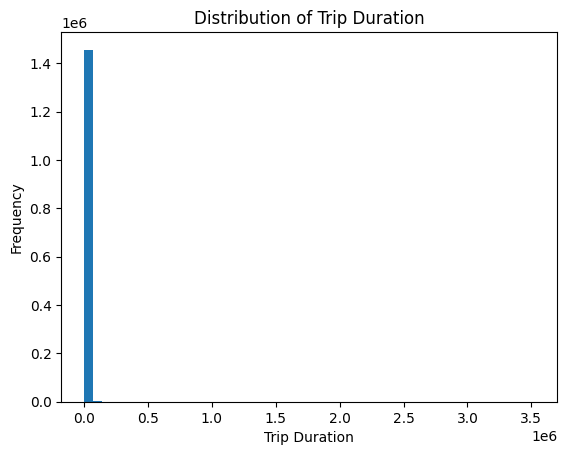

In [14]:
import matplotlib.pyplot as plt

plt.hist(df['trip_duration'], bins=50)
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Trip Duration")
plt.show()

In [15]:
df['trip_duration'].quantile([0.90,0.95,0.99,0.999])

0.900     1634.000
0.950     2104.000
0.990     3440.000
0.999    85128.357
Name: trip_duration, dtype: float64

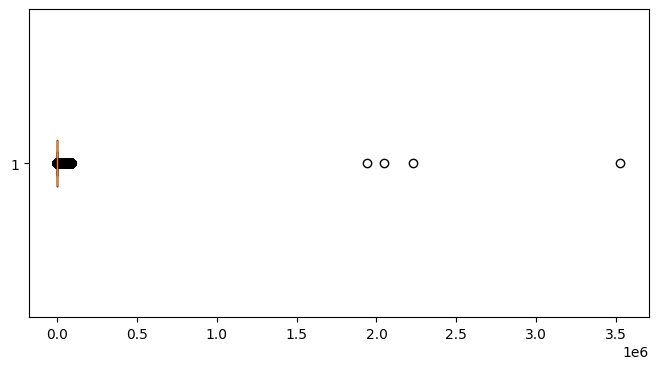

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(df['trip_duration'], vert=False)
plt.show()

In [17]:
(df['trip_duration'] > 3440).sum()

np.int64(14575)

In [18]:
(df['trip_duration'] > 85128).sum()

np.int64(1459)

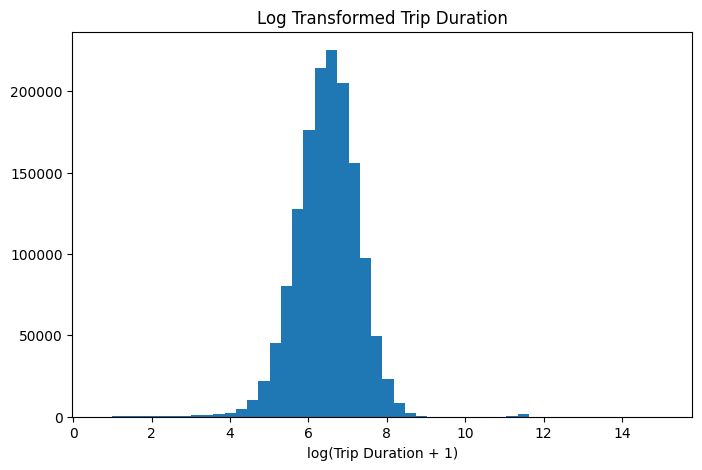

In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['trip_duration']), bins=50)
plt.xlabel("log(Trip Duration + 1)")
plt.title("Log Transformed Trip Duration")
plt.show()